In [2]:
import pandas as pd
import numpy as np 

df = pd.read_csv('CTG.csv')
print("Primeras 5 filas del dataset:")
print(df.head())

Primeras 5 filas del dataset:
       FileName       Date      SegFile      b       e    LBE     LB   AC  \
0  Variab10.txt  12/1/1996  CTG0001.txt  240.0   357.0  120.0  120.0  0.0   
1    Fmcs_1.txt   5/3/1996  CTG0002.txt    5.0   632.0  132.0  132.0  4.0   
2    Fmcs_1.txt   5/3/1996  CTG0003.txt  177.0   779.0  133.0  133.0  2.0   
3    Fmcs_1.txt   5/3/1996  CTG0004.txt  411.0  1192.0  134.0  134.0  2.0   
4    Fmcs_1.txt   5/3/1996  CTG0005.txt  533.0  1147.0  132.0  132.0  4.0   

    FM   UC  ...    C    D    E   AD   DE   LD   FS  SUSP  CLASS  NSP  
0  0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0  0.0  1.0   0.0    9.0  2.0  
1  0.0  4.0  ...  0.0  0.0  0.0  1.0  0.0  0.0  0.0   0.0    6.0  1.0  
2  0.0  5.0  ...  0.0  0.0  0.0  1.0  0.0  0.0  0.0   0.0    6.0  1.0  
3  0.0  6.0  ...  0.0  0.0  0.0  1.0  0.0  0.0  0.0   0.0    6.0  1.0  
4  0.0  5.0  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0    2.0  1.0  

[5 rows x 40 columns]


##### Hay columnas con datos inecesarios por lo que hemos decidido eliminarlos.

In [3]:
# Eliminamos columnas de metadatos que no sirven para predicción
cols_drop = ['FileName', 'Date', 'SegFile', 'b', 'e']
df = df.drop(columns=cols_drop, errors='ignore')

In [4]:
df

,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,120.0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,132.0,132.0,4.0,0.0,4.0,17.0,2.1,0.0,10.4,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,133.0,133.0,2.0,0.0,5.0,16.0,2.1,0.0,13.4,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,134.0,134.0,2.0,0.0,6.0,16.0,2.4,0.0,23.0,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,132.0,132.0,4.0,0.0,5.0,16.0,2.4,0.0,19.9,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,140.0,140.0,1.0,0.0,9.0,78.0,0.4,27.0,7.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2125,142.0,142.0,1.0,1.0,5.0,74.0,0.4,36.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Nulos por columna
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

LBE         3
LB          3
AC          3
FM          2
UC          2
ASTV        2
MSTV        2
ALTV        2
MLTV        2
DL          1
DS          1
DP          1
DR          1
Width       3
Min         3
Max         3
Nmax        3
Nzeros      3
Mode        3
Mean        3
Median      3
Variance    3
Tendency    3
A           3
B           3
C           3
D           3
E           3
AD          3
DE          3
LD          3
FS          3
SUSP        3
CLASS       3
NSP         3
dtype: int64


In [6]:
df.describe()

,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
count,2126.000000,2126.000000,2126.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2128.000000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.303857,133.303857,2.722484,7.503056,3.669017,47.008933,1.335449,9.884814,8.207616,1.576128,...,0.024929,0.038100,0.033866,0.156162,0.118532,0.050329,0.032455,0.092662,4.509878,1.304327
std,9.840844,9.840844,3.560850,39.030452,2.877148,17.210648,0.891543,18.476534,5.701926,2.517794,...,0.155947,0.191482,0.180928,0.363094,0.323314,0.218675,0.177248,0.290027,3.026883,0.614377
min,106.000000,106.000000,0.000000,0.000000,0.000000,12.000000,0.200000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,126.000000,126.000000,0.000000,0.000000,1.000000,32.000000,0.700000,0.000000,4.600000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000
50%,133.000000,133.000000,1.000000,0.000000,3.000000,49.000000,1.200000,0.000000,7.400000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000
75%,140.000000,140.000000,4.000000,2.000000,5.000000,61.000000,1.700000,11.000000,10.800000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,1.000000
max,160.000000,160.000000,26.000000,564.000000,23.000000,87.000000,7.000000,91.000000,50.700000,16.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,3.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 35 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LBE       2126 non-null   float64
 1   LB        2126 non-null   float64
 2   AC        2126 non-null   float64
 3   FM        2127 non-null   float64
 4   UC        2127 non-null   float64
 5   ASTV      2127 non-null   float64
 6   MSTV      2127 non-null   float64
 7   ALTV      2127 non-null   float64
 8   MLTV      2127 non-null   float64
 9   DL        2128 non-null   float64
 10  DS        2128 non-null   float64
 11  DP        2128 non-null   float64
 12  DR        2128 non-null   float64
 13  Width     2126 non-null   float64
 14  Min       2126 non-null   float64
 15  Max       2126 non-null   float64
 16  Nmax      2126 non-null   float64
 17  Nzeros    2126 non-null   float64
 18  Mode      2126 non-null   float64
 19  Mean      2126 non-null   float64
 20  Median    2126 non-null   floa

In [10]:
df[df['NSP'].isnull()]

,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2128,NaN,NaN,NaN,564.0,23.0,87.0,7.0,91.0,50.7,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### La variable objetivo (NSP) tiene valores nulos. No nos sirve mantener datos donde la variable objetivo es NULL por lo que eliminaremos esos registros.

In [11]:
df_clean = df.dropna(subset=['NSP'])

In [12]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2126 entries, 0 to 2125
Data columns (total 35 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LBE       2126 non-null   float64
 1   LB        2126 non-null   float64
 2   AC        2126 non-null   float64
 3   FM        2126 non-null   float64
 4   UC        2126 non-null   float64
 5   ASTV      2126 non-null   float64
 6   MSTV      2126 non-null   float64
 7   ALTV      2126 non-null   float64
 8   MLTV      2126 non-null   float64
 9   DL        2126 non-null   float64
 10  DS        2126 non-null   float64
 11  DP        2126 non-null   float64
 12  DR        2126 non-null   float64
 13  Width     2126 non-null   float64
 14  Min       2126 non-null   float64
 15  Max       2126 non-null   float64
 16  Nmax      2126 non-null   float64
 17  Nzeros    2126 non-null   float64
 18  Mode      2126 non-null   float64
 19  Mean      2126 non-null   float64
 20  Median    2126 non-null   float64
 

##### Ya no hay columnas con NULL. Ya no es necesario realizar limpiezas en este aspecto.

C:\Users\miguel.salas\AppData\Local\Temp\ipykernel_15076\2408167591.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='NSP', data=df_clean, palette='viridis')


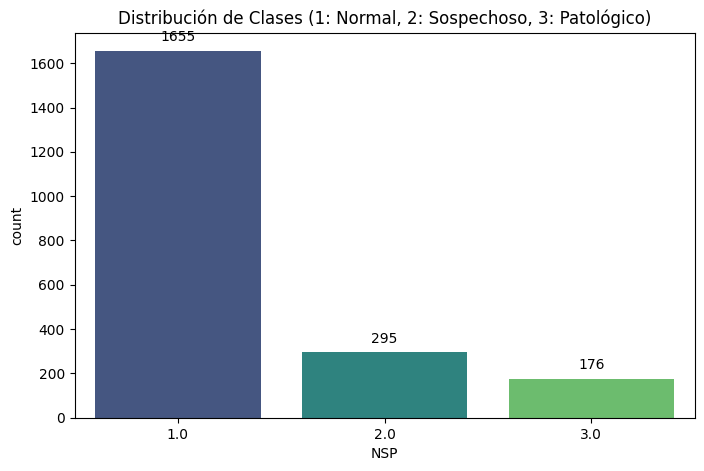

NSP
1.0    77.845720
2.0    13.875823
3.0     8.278457
Name: proportion, dtype: float64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

ax = sns.countplot(x='NSP', data=df_clean, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('Distribución de Clases (1: Normal, 2: Sospechoso, 3: Patológico)')
plt.show()

print(df_clean['NSP'].value_counts(normalize=True) * 100)

##### El dataset está muy desbalanceado. Para el entrenamiento, aunque se divida 80/20, mantendremos las proporciones para no tener el riesgo de eliminar todos los Patológicos.

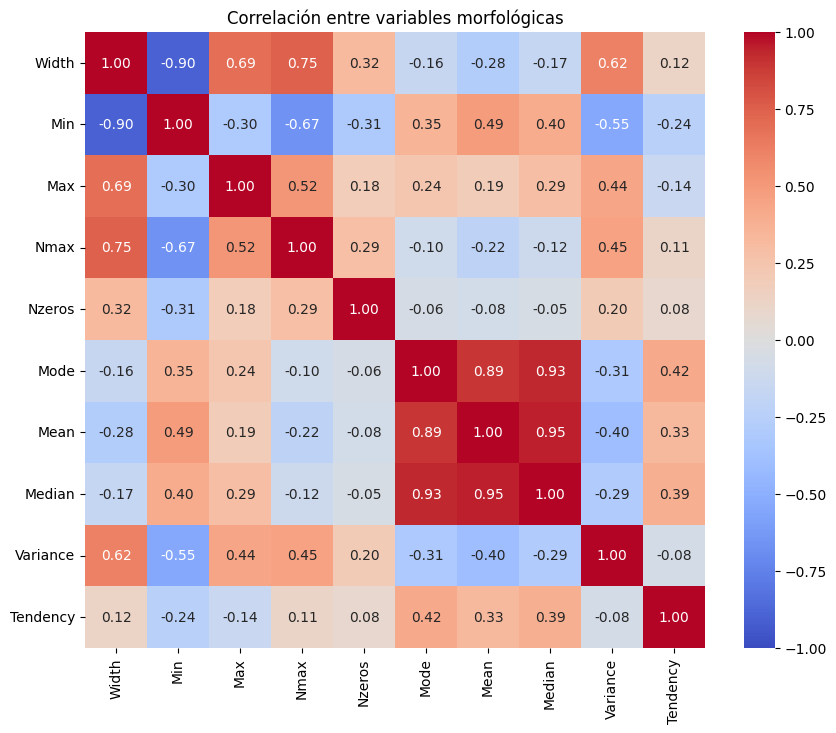

In [14]:
morph_cols = ['Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[morph_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre variables morfológicas')
plt.show()

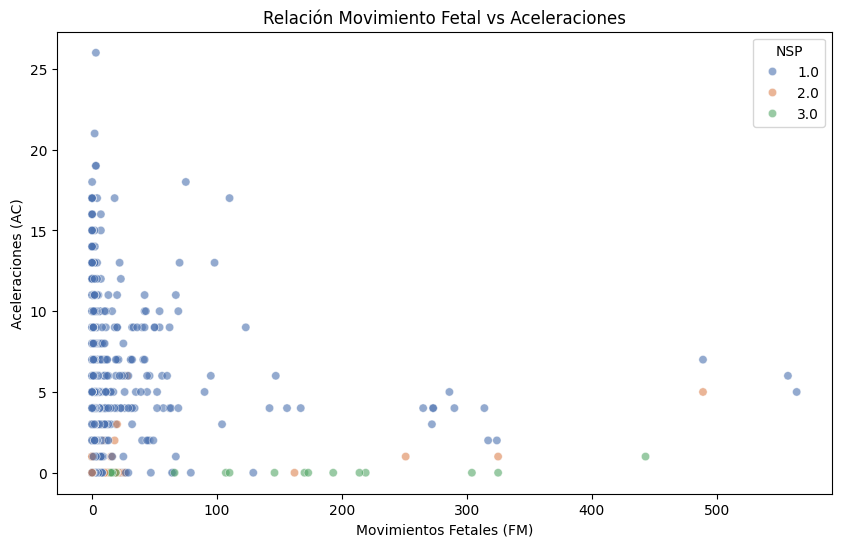

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='FM', y='AC', hue='NSP', data=df_clean, palette='deep', alpha=0.6)
plt.title('Relación Movimiento Fetal vs Aceleraciones')
plt.xlabel('Movimientos Fetales (FM)')
plt.ylabel('Aceleraciones (AC)')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_clean.drop(columns=['NSP', 'CLASS']) 
y = df_clean['NSP']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,     
    random_state=42,  
    stratify=y        
)

print("Proporción de Patológicos (Clase 3) en Train:", (y_train == 3).mean())
print("Proporción de Patológicos (Clase 3) en Test: ", (y_test == 3).mean())

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nDimensiones finales:")
print(f"Train: {X_train_scaled.shape}")
print(f"Test:  {X_test_scaled.shape}")

Proporción de Patológicos (Clase 3) en Train: 0.08294117647058824
Proporción de Patológicos (Clase 3) en Test:  0.08215962441314555

Dimensiones finales:
Train: (1700, 33)
Test:  (426, 33)


#### Hemos dividido nuestro dataset en train y test. Mantuvimos la proporción para no tener el riesgo de eliminar las 2 clases con pocos registros. Ya que una muestra al azar tendría el riesog de elimianar los registros.

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

svc_base = SVC(random_state=42)

svc_base.fit(X_train_scaled, y_train)

y_pred_base = svc_base.predict(X_test_scaled)

print("Reporte del Modelo Base (SVC Default)")
print(classification_report(y_test, y_pred_base))

--- Reporte del Modelo Base (SVC Default) ---
              precision    recall  f1-score   support

         1.0       0.98      1.00      0.99       332
         2.0       1.00      0.90      0.95        59
         3.0       0.97      1.00      0.99        35

    accuracy                           0.98       426
   macro avg       0.98      0.97      0.97       426
weighted avg       0.98      0.98      0.98       426



#### Hemos realizado un modelo base para tener una referencia.

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import numpy as np

param_dist = {
    'C': [0.1, 1, 10, 100, 1000],  
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001], 
    'kernel': ['rbf', 'poly', 'sigmoid'], 
    'degree': randint(2, 6) 
}

random_search = RandomizedSearchCV(
    estimator=SVC(random_state=42, class_weight='balanced'), 
    param_distributions=param_dist,
    n_iter=20,
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    random_state=42
)

print("RandomizedSearchCV")
random_search.fit(X_train_scaled, y_train)

print(f"Mejores parámetros Random: {random_search.best_params_}")
print(f"Mejor Score (F1 Weighted): {random_search.best_score_:.4f}")

RandomizedSearchCV
Mejores parámetros Random: {'C': 10, 'degree': 5, 'gamma': 0.01, 'kernel': 'rbf'}
Mejor Score (F1 Weighted): 0.9911


#### Se encontraron valores óptimos cercanos a C=10 y gamma=0.01

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report

param_grid = {
    'C': [5, 8, 10, 12, 15],         
    'gamma': [0.005, 0.008, 0.01, 0.012, 0.02],
    'kernel': ['rbf']                
}

grid_search = GridSearchCV(
    estimator=SVC(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1 
)

print("GridSearchCV")
grid_search.fit(X_train_scaled, y_train)

print(f"\nMejores parámetros Grid: {grid_search.best_params_}")
print(f"Mejor Score Grid: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

print("\nREPORTE FINAL DEL MODELO OPTIMIZADO")
y_pred_opt = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_opt))

GridSearchCV
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Mejores parámetros Grid: {'C': 12, 'gamma': 0.005, 'kernel': 'rbf'}
Mejor Score Grid: 0.9924

REPORTE FINAL DEL MODELO OPTIMIZADO
              precision    recall  f1-score   support

         1.0       0.99      0.99      0.99       332
         2.0       0.97      0.97      0.97        59
         3.0       0.97      1.00      0.99        35

    accuracy                           0.99       426
   macro avg       0.98      0.99      0.98       426
weighted avg       0.99      0.99      0.99       426



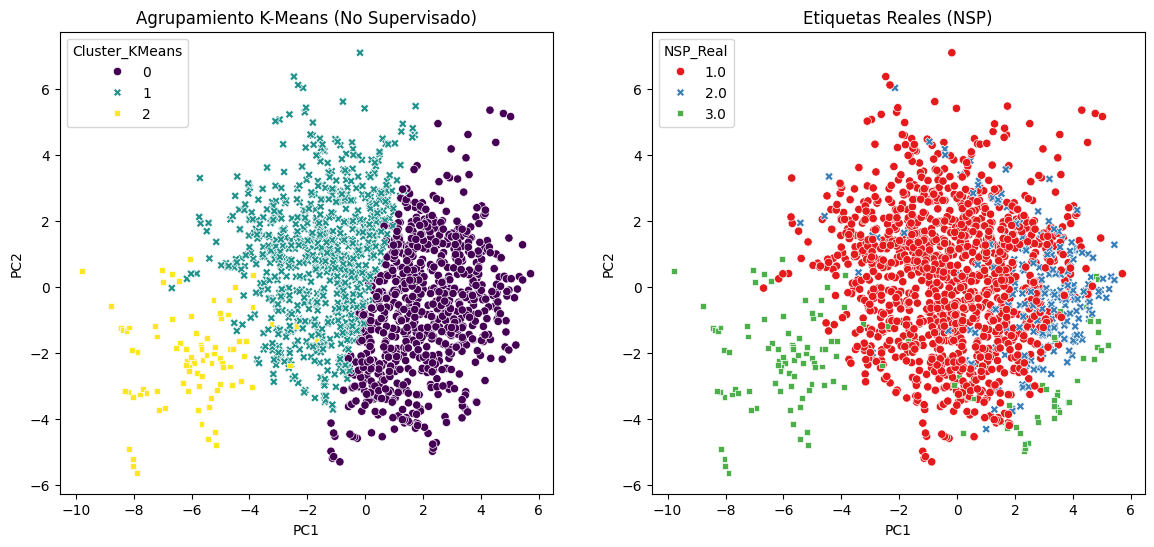


Comparación: Clusters Generados vs Realidad
Cluster K-Means    0    1   2
Realidad                     
1.0              562  761   0
2.0              214   22   0
3.0               53    0  88


In [21]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster_KMeans'] = clusters
df_pca['NSP_Real'] = y_train.values

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='PC1', y='PC2', hue='Cluster_KMeans', data=df_pca, palette='viridis', style='Cluster_KMeans')
plt.title('Agrupamiento K-Means (No Supervisado)')

plt.subplot(1, 2, 2)
sns.scatterplot(x='PC1', y='PC2', hue='NSP_Real', data=df_pca, palette='Set1', style='NSP_Real')
plt.title('Etiquetas Reales (NSP)')

plt.show()

print("\nComparación: Clusters Generados vs Realidad")
print(pd.crosstab(df_pca['NSP_Real'], df_pca['Cluster_KMeans'], rownames=['Realidad'], colnames=['Cluster K-Means']))

#### K-Means es capaz de detectar los casos más extremos pero carece de la precisión necesaria para desambiguar pacientes sospechosos, confirmando la necesidad de utilizar modelos supervisados que sí logran separar estas clases con una alta presición.